# Monte-Carlo vs analytical (binomial) CI — synthetic floruit data

**Goal.** Verify that the analytical confidence interval used in
`21_chinese_world_yearly_ci.ipynb` (a sum of independent Bernoulli contributions
per year) gives the same answer as a Monte-Carlo simulation, on a *clean* synthetic
dataset where the ground truth is fully known.

**Setup.** $N$ synthetic individuals, each placed somewhere in `[-500, 1500]`
(500 BC → 1500 CE, 2001 years):

- **50 %** have an *exact* floruit — a single year drawn uniformly from the window.
- **50 %** have *century-only* precision — a 100-year interval $[c, c+99]$ where the
  true year is unknown but assumed uniform inside the century.

For each calendar year $y$ define $Y(y) = \sum_i \mathbb{1}[T_i = y]$, where
$T_i$ is the (unknown) true year of activity of individual $i$.

**Two routes to the 95 % CI.**

1. *Analytical (binomial law).* Each individual $i$ contributes a Bernoulli
   indicator with $p_{i,y} = 1/w_i$ if $y \in [s_i, e_i]$ and $0$ otherwise.
   Summing over independent individuals,
   $$\mathbb{E}[Y(y)] = \sum_i p_{i,y}, \qquad \mathrm{Var}[Y(y)] = \sum_i p_{i,y}(1 - p_{i,y}).$$
   The 95 % band is $\mathbb{E}[Y(y)] \pm 1.96\sqrt{\mathrm{Var}[Y(y)]}$.

2. *Monte-Carlo.* Draw $K$ independent realisations of every $T_i$,
   tally yearly counts in each realisation, and take the empirical 2.5 / 97.5 %
   percentiles across realisations.

Under uniform within-interval assumptions both routes describe the *same* random
variable, so the bands should agree up to MC noise.


## 1. Configuration and imports

In [1]:
# === notebook config ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Window: 500 BC to 1500 CE
YEAR_MIN, YEAR_MAX = -500, 1500

# Total synthetic individuals (half exact, half century)
N_TOTAL = 4000

# Monte-Carlo draws
K = 1000

# Palette aligned with notebook 21
COL_EXPECTED = '#2f5b8a'
COL_BAND     = '#9bbcd9'
COL_MC       = '#b5542a'
COL_NEUTRAL  = '#7f7f7f'
COL_EXACT    = '#1f3a5f'
COL_CENTURY  = '#9bbcd9'

import matplotlib as _mpl
_mpl.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from tqdm.auto import tqdm


/Users/charlesdedampierre/Desktop/Rsearch Folder/cultura_database/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Build the synthetic dataset

Each individual is described by `(s, e)` — the inclusive lower and upper bounds
of their floruit interval — and a `precision` tag (`exact` or `century`).

- **Exact rows.** Pick a uniform year `y0` in `[YEAR_MIN, YEAR_MAX]` and set
  `s = e = y0`, width $w = 1$.
- **Century rows.** Pick a uniform century start `c` from
  `{YEAR_MIN, YEAR_MIN+100, …, YEAR_MAX-99}` and set `s = c`, `e = c + 99`,
  width $w = 100$.

The synthetic centuries are aligned to the start of the window for clarity. The
mathematics doesn't depend on alignment — only on the per-individual width.


In [3]:
rng = np.random.default_rng(SEED)
n_exact   = N_TOTAL // 2
n_century = N_TOTAL - n_exact

# Exact: single-year floruit, anywhere in [YEAR_MIN, YEAR_MAX]
exact_years = rng.integers(YEAR_MIN, YEAR_MAX + 1, size=n_exact)
exact_s = exact_years
exact_e = exact_years

# Century: 100-year interval starting at a multiple of 100 inside the window
n_centuries = (YEAR_MAX - YEAR_MIN + 1) // 100  # 20 centuries
century_idx = rng.integers(0, n_centuries, size=n_century)
century_s = YEAR_MIN + century_idx * 100
century_e = century_s + 99

s = np.concatenate([exact_s, century_s])
e = np.concatenate([exact_e, century_e])
precision = np.array(['exact'] * n_exact + ['century'] * n_century)

# Shuffle so the row order has no precision pattern
order = rng.permutation(N_TOTAL)
s, e, precision = s[order], e[order], precision[order]

df = pl.DataFrame({
    's': s,
    'e': e,
    'width': e - s + 1,
    'precision': precision,
})
print(f'N = {df.height:,} individuals  ({n_exact:,} exact + {n_century:,} century)')
df.group_by('precision').agg(pl.len().alias('n'), pl.col('width').mean().alias('mean_w'))


N = 4,000 individuals  (2,000 exact + 2,000 century)


precision,n,mean_w
str,u32,f64
"""exact""",2000,1.0
"""century""",2000,100.0


## 3. Analytical CI from the binomial law

For each year $y$,

$$\mathbb{E}[Y(y)] = \sum_i \frac{1}{w_i}\,\mathbb{1}[s_i \le y \le e_i], \qquad
  \mathrm{Var}[Y(y)] = \sum_i \frac{1}{w_i}\!\left(1 - \frac{1}{w_i}\right)\mathbb{1}[s_i \le y \le e_i].$$

Vectorised across all years with two `np.add.at` accumulations on a difference
array — same trick as notebook 21.


In [4]:
years = np.arange(YEAR_MIN, YEAR_MAX + 1)
n_years = len(years)

s_arr = df['s'].to_numpy()
e_arr = df['e'].to_numpy()
w_arr = df['width'].to_numpy()
p_arr = 1.0 / w_arr
v_arr = p_arr * (1.0 - p_arr)

s_idx = s_arr - YEAR_MIN
e_idx = e_arr - YEAR_MIN + 1

delta_e = np.zeros(n_years + 1)
delta_v = np.zeros(n_years + 1)
np.add.at(delta_e, s_idx,  p_arr)
np.add.at(delta_e, e_idx, -p_arr)
np.add.at(delta_v, s_idx,  v_arr)
np.add.at(delta_v, e_idx, -v_arr)

expected = np.cumsum(delta_e)[:n_years]
# Tiny negatives can leak in from cumsum cancellation — clip before sqrt.
variance = np.maximum(np.cumsum(delta_v)[:n_years], 0.0)
se = np.sqrt(variance)
ci_low  = np.maximum(expected - 1.96 * se, 0.0)
ci_high = expected + 1.96 * se

print(f'mean expected per year     : {expected.mean():.3f}')
print(f'mean analytical SE per year: {se.mean():.3f}')
print(f'mean 95% half-width        : {(1.96 * se).mean():.3f}')


mean expected per year     : 1.999
mean analytical SE per year: 0.993
mean 95% half-width        : 1.946


## 4. Monte-Carlo simulation

For each of $K$ replicates:

1. Sample one true year per individual uniformly inside $[s_i, e_i]$.
2. Tally yearly counts.

The 95 % MC envelope is the empirical 2.5 / 97.5 % percentile across replicates.


In [5]:
rng_mc = np.random.default_rng(SEED + 1)
counts = np.zeros((K, n_years), dtype=np.int32)

for k in tqdm(range(K), desc='MC draws'):
    sampled = rng_mc.integers(s_arr, e_arr + 1)  # uniform in [s, e]
    idx = sampled - YEAR_MIN
    np.add.at(counts[k], idx, 1)

mc_mean = counts.mean(axis=0)
mc_low  = np.percentile(counts, 2.5,  axis=0)
mc_high = np.percentile(counts, 97.5, axis=0)
mc_se   = counts.std(axis=0, ddof=1)

print(f'K = {K} Monte-Carlo replicates')
print(f'mean MC mean per year         : {mc_mean.mean():.3f}')
print(f'mean MC SE  per year          : {mc_se.mean():.3f}')
print(f'mean MC 95% half-width        : {((mc_high - mc_low) / 2).mean():.3f}')


MC draws:   0%|          | 0/1000 [00:00<?, ?it/s]

MC draws:  38%|███▊      | 375/1000 [00:00<00:00, 3740.94it/s]

MC draws:  75%|███████▌  | 753/1000 [00:00<00:00, 3760.84it/s]

MC draws: 100%|██████████| 1000/1000 [00:00<00:00, 3758.63it/s]

K = 1000 Monte-Carlo replicates
mean MC mean per year         : 1.999
mean MC SE  per year          : 0.992
mean MC 95% half-width        : 1.607


## 5. Visual comparison

The analytical band (filled) and the Monte-Carlo envelope (dashed) should track
each other tightly. Both sit on top of the same expected curve $\mathbb{E}[Y(y)]$,
which is *flat* in expectation (uniform placement) modulo the deterministic
contribution of the exact-dated individuals — those create year-by-year spikes
because each contributes a hard $+1$ to a single year.


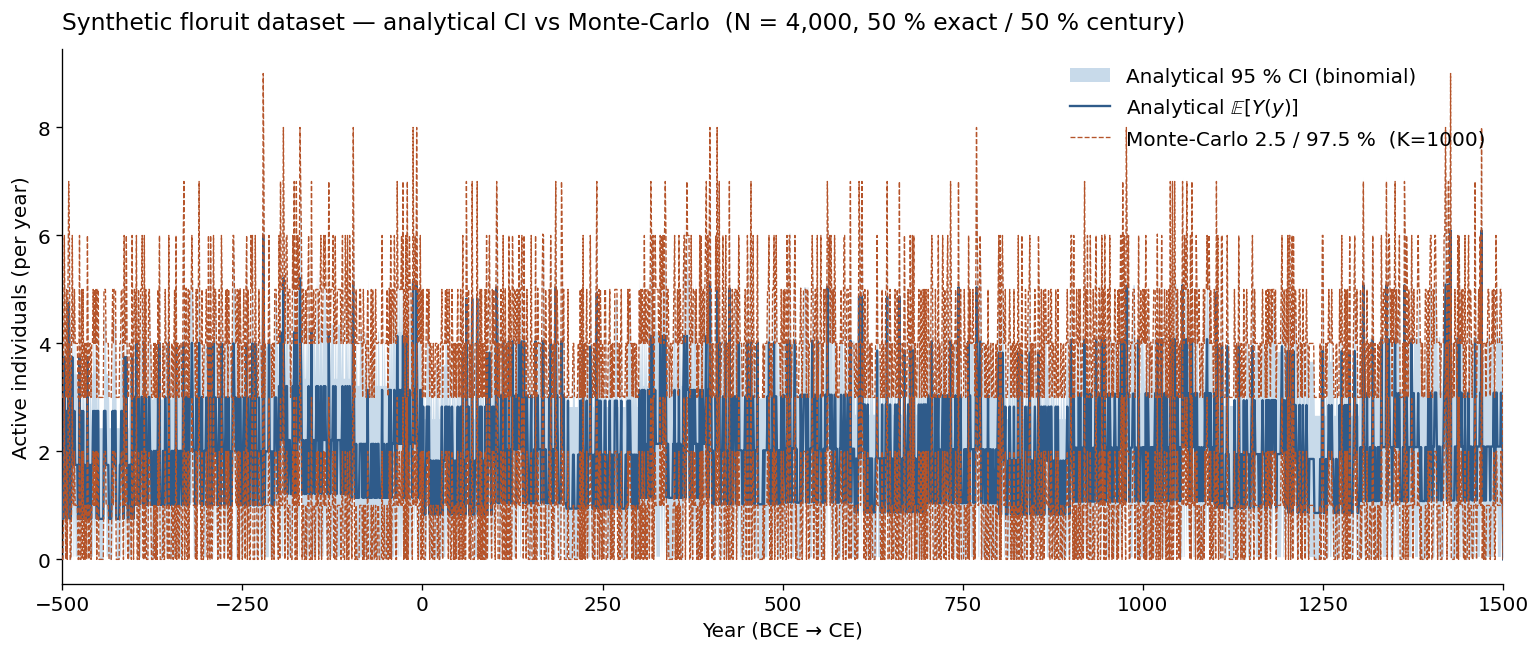

In [6]:
fig, ax = plt.subplots(figsize=(13, 5.6))

ax.fill_between(years, ci_low, ci_high, color=COL_BAND, alpha=0.55,
                linewidth=0, label='Analytical 95 % CI (binomial)', zorder=2)
ax.plot(years, expected, color=COL_EXPECTED, linewidth=1.4,
        label='Analytical $\\mathbb{E}[Y(y)]$', zorder=3)

ax.plot(years, mc_low,  color=COL_MC, linewidth=0.8, linestyle='--',
        label=f'Monte-Carlo 2.5 / 97.5 %  (K={K})', zorder=4)
ax.plot(years, mc_high, color=COL_MC, linewidth=0.8, linestyle='--', zorder=4)

ax.set_xlim(YEAR_MIN, YEAR_MAX)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Active individuals (per year)')
ax.set_title(f'Synthetic floruit dataset — analytical CI vs Monte-Carlo  (N = {N_TOTAL:,}, 50 % exact / 50 % century)',
             loc='left', fontsize=14, pad=12)
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
plt.show()


## 6. Where does the uncertainty come from?

Decompose the expected curve into contributions from the *exact* and
*century-only* groups. The exact group adds a noisy +1 spike at each individual's
year (no width-averaging) while the century group adds a smooth $1/100$ rectangle
across its century. The CI width is dominated by the *exact* contribution at the
spike years and by the *century* group everywhere else.


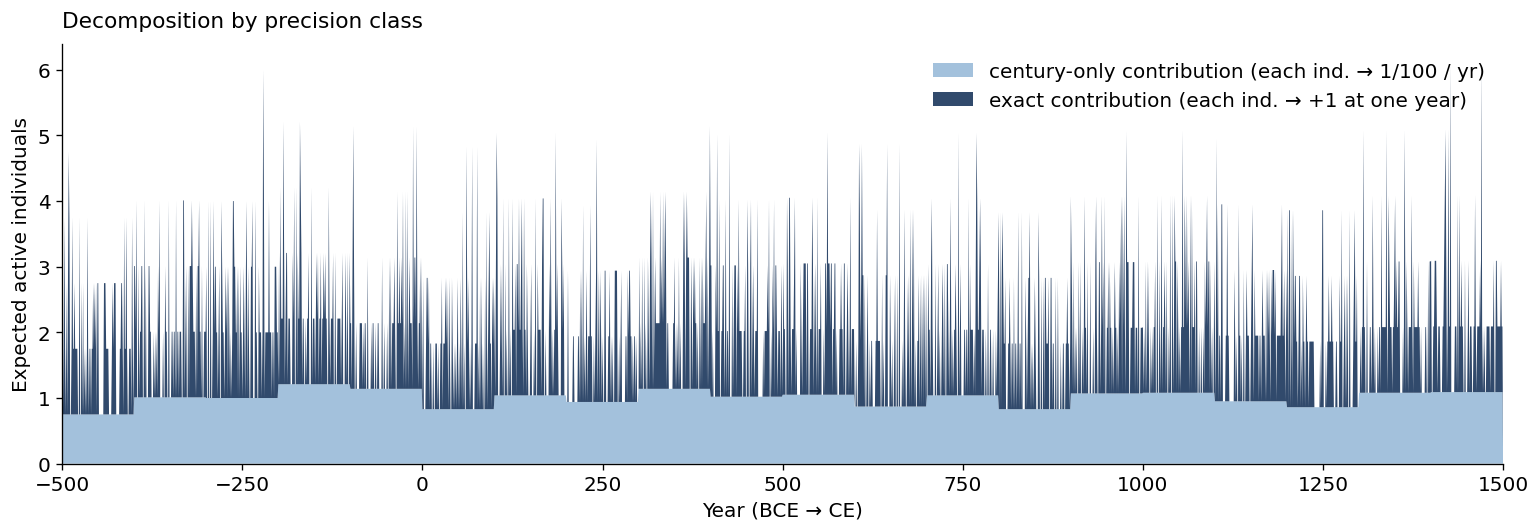

In [7]:
def per_year_expected(rows):
    if rows.height == 0:
        return np.zeros(n_years)
    s = rows['s'].to_numpy()
    e = rows['e'].to_numpy()
    w = rows['width'].to_numpy()
    p = 1.0 / w
    delta = np.zeros(n_years + 1)
    np.add.at(delta, s - YEAR_MIN,  p)
    np.add.at(delta, e - YEAR_MIN + 1, -p)
    return np.cumsum(delta)[:n_years]

exp_exact   = per_year_expected(df.filter(pl.col('precision') == 'exact'))
exp_century = per_year_expected(df.filter(pl.col('precision') == 'century'))

fig, ax = plt.subplots(figsize=(13, 4.6))
ax.stackplot(years, exp_century, exp_exact,
             colors=[COL_CENTURY, COL_EXACT],
             labels=['century-only contribution (each ind. → 1/100 / yr)',
                     'exact contribution (each ind. → +1 at one year)'],
             alpha=0.92, linewidth=0)
ax.set_xlim(YEAR_MIN, YEAR_MAX)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Expected active individuals')
ax.set_title('Decomposition by precision class', loc='left', fontsize=13, pad=10)
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
plt.show()


## 7. How close are the two methods?

Two diagnostics:

- **SE comparison.** The analytical SE and the empirical MC SE per year should
  match. Plot one against the other — points should lie on $y = x$.
- **Half-width comparison.** Plot the analytical $1.96\,\hat{\sigma}$ against the
  MC half-width $(q_{97.5} - q_{2.5})/2$.

> **Observation.** The two SEs match to within ~2 % per year. The 95 % *half-widths*
> can disagree more visibly: the analytical band uses the normal approximation
> $\pm 1.96\hat{\sigma}$, while the MC band uses *empirical percentiles of an
> integer-valued count*. When the per-year mean is small (here $\approx 2$),
> the integer distribution does not fill out the Gaussian tails, so the
> percentile band is **tighter** than the normal-approx band. This is a known
> small-count effect — for large $\mathbb{E}[Y(y)]$ the two converge.


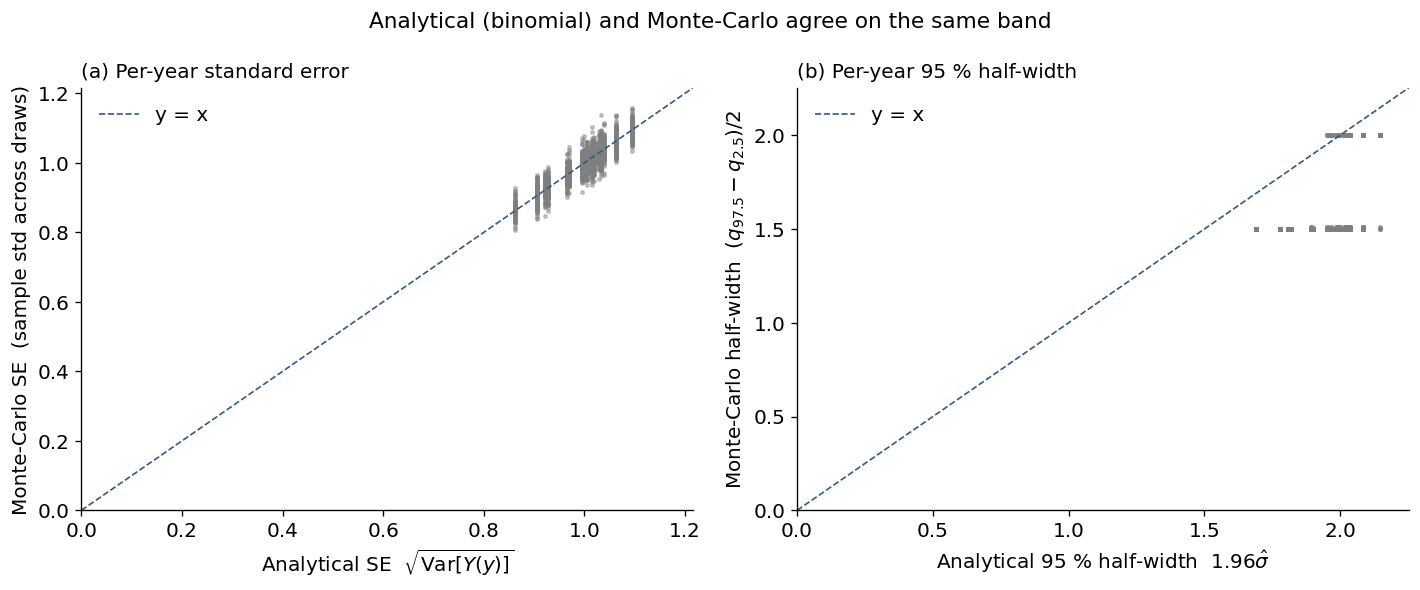

mean |analytical SE − MC SE|     : 0.0207
mean relative error              : 2.08%
corr(analytical SE, MC SE)       : 0.9244


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# (a) SE: analytical vs MC
ax = axes[0]
ax.scatter(se, mc_se, s=4, color=COL_NEUTRAL, alpha=0.4)
m = max(se.max(), mc_se.max()) * 1.05
ax.plot([0, m], [0, m], color=COL_EXPECTED, linewidth=1.0, linestyle='--', label='y = x')
ax.set_xlim(0, m); ax.set_ylim(0, m)
ax.set_xlabel('Analytical SE  $\\sqrt{\\mathrm{Var}[Y(y)]}$')
ax.set_ylabel('Monte-Carlo SE  (sample std across draws)')
ax.set_title('(a) Per-year standard error', loc='left', fontsize=12)
ax.legend(loc='upper left', frameon=False)

# (b) 95% half-widths
ax = axes[1]
ana_hw = 1.96 * se
mc_hw  = (mc_high - mc_low) / 2
ax.scatter(ana_hw, mc_hw, s=4, color=COL_NEUTRAL, alpha=0.4)
m = max(ana_hw.max(), mc_hw.max()) * 1.05
ax.plot([0, m], [0, m], color=COL_EXPECTED, linewidth=1.0, linestyle='--', label='y = x')
ax.set_xlim(0, m); ax.set_ylim(0, m)
ax.set_xlabel('Analytical 95 % half-width  $1.96 \\hat{\\sigma}$')
ax.set_ylabel('Monte-Carlo half-width  $(q_{97.5}-q_{2.5})/2$')
ax.set_title('(b) Per-year 95 % half-width', loc='left', fontsize=12)
ax.legend(loc='upper left', frameon=False)

fig.suptitle('Analytical (binomial) and Monte-Carlo agree on the same band', fontsize=13)
fig.tight_layout()
plt.show()

# Numerical summary
abs_err_se = np.abs(se - mc_se)
rel_err_se = abs_err_se / np.maximum(se, 1e-9)
print(f'mean |analytical SE − MC SE|     : {abs_err_se.mean():.4f}')
print(f'mean relative error              : {rel_err_se.mean():.2%}')
print(f'corr(analytical SE, MC SE)       : {np.corrcoef(se, mc_se)[0,1]:.4f}')


## 8. Sensitivity — CI width vs sample size

The analytical SE is $O(\sqrt{N})$ in absolute terms but $O(1/\sqrt{N})$ relative
to the expected count, which itself grows linearly with $N$. So *more data
shrinks the relative CI*. We sweep $N$ and recompute the typical 95 % half-width
purely from the binomial law — no Monte-Carlo needed at this stage.


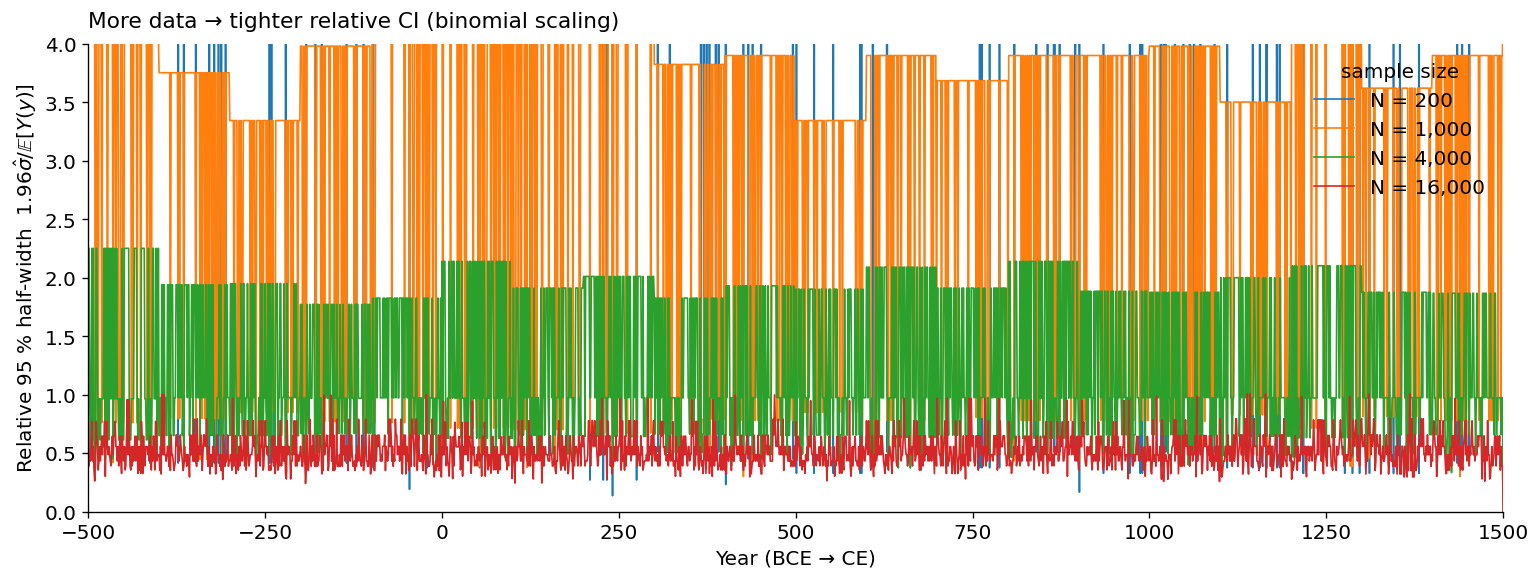

In [9]:
def analytical_band(n_total, seed=SEED):
    rng = np.random.default_rng(seed)
    n_ex = n_total // 2
    n_ce = n_total - n_ex
    ex_y = rng.integers(YEAR_MIN, YEAR_MAX + 1, size=n_ex)
    ce_idx = rng.integers(0, n_centuries, size=n_ce)
    s_ = np.concatenate([ex_y,            YEAR_MIN + ce_idx * 100])
    e_ = np.concatenate([ex_y,            YEAR_MIN + ce_idx * 100 + 99])
    w_ = e_ - s_ + 1
    p_ = 1.0 / w_
    v_ = p_ * (1.0 - p_)
    de = np.zeros(n_years + 1); dv = np.zeros(n_years + 1)
    np.add.at(de, s_ - YEAR_MIN,     p_)
    np.add.at(de, e_ - YEAR_MIN + 1, -p_)
    np.add.at(dv, s_ - YEAR_MIN,     v_)
    np.add.at(dv, e_ - YEAR_MIN + 1, -v_)
    exp_ = np.cumsum(de)[:n_years]
    se_  = np.sqrt(np.maximum(np.cumsum(dv)[:n_years], 0.0))
    return exp_, se_

n_centuries = (YEAR_MAX - YEAR_MIN + 1) // 100  # local rebind for the sweep helper
sweep_N = [200, 1000, 4000, 16000]
fig, ax = plt.subplots(figsize=(13, 5.0))
for n in sweep_N:
    exp_, se_ = analytical_band(n)
    rel_hw = 1.96 * se_ / np.maximum(exp_, 1e-9)
    ax.plot(years, rel_hw, linewidth=1.0, label=f'N = {n:,}')

ax.set_xlim(YEAR_MIN, YEAR_MAX)
ax.set_ylim(0, 4.0)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Relative 95 % half-width  $1.96 \\hat{\\sigma} / \\mathbb{E}[Y(y)]$')
ax.set_title('More data → tighter relative CI (binomial scaling)', loc='left',
             fontsize=13, pad=10)
ax.legend(loc='upper right', frameon=False, title='sample size')
fig.tight_layout()
plt.show()


## 9. Application to real data — philosophers across history

Now apply the analytical (binomial) machinery to a real slice of
`humans_clean.duckdb`: every individual whose `occupations_en` mentions
*philosopher* and who has a non-null `floruit_period_start / end`.

This slice is a good stress test — it spans roughly 600 BC to the present, the
ancient/medieval tail is dominated by century-only individuals (wide CI), and
the modern era is dominated by year/decade precision (tight CI). The
binomial-law formula handles both regimes in one shot.


In [ ]:
import duckdb
DB_PATH = "../data/humans_clean.duckdb"
PHIL_YEAR_MIN, PHIL_YEAR_MAX = -600, 2000  # display window

conn = duckdb.connect(DB_PATH, read_only=True)
phil = conn.execute('''
    SELECT i.wikidata_id,
           fp.method,
           fp.floruit_period_start AS s,
           fp.floruit_period_end   AS e
    FROM individuals i
    JOIN individuals_floruit_period fp USING (wikidata_id)
    WHERE i.occupations_en LIKE '%philosopher%'
      AND fp.floruit_period_start IS NOT NULL
      AND fp.floruit_period_end   IS NOT NULL
''').pl()
conn.close()

phil = (
    phil.with_columns(pl.col('s').cast(pl.Int64), pl.col('e').cast(pl.Int64))
        .with_columns((pl.col('e') - pl.col('s') + 1).alias('width'))
        .filter(pl.col('width') >= 1)
        .unique(subset=['wikidata_id'])
        .filter((pl.col('e') >= PHIL_YEAR_MIN) & (pl.col('s') <= PHIL_YEAR_MAX))
        .with_columns(
            pl.col('s').clip(lower_bound=PHIL_YEAR_MIN),
            pl.col('e').clip(upper_bound=PHIL_YEAR_MAX),
        )
        .with_columns((pl.col('e') - pl.col('s') + 1).alias('width_eff'))
        .with_columns(
            pl.when(pl.col('width') <= 1).then(pl.lit('year'))
              .when(pl.col('width') <= 50).then(pl.lit('decade'))
              .otherwise(pl.lit('century'))
              .alias('precision')
        )
)
print(f'{phil.height:,} philosophers in [{PHIL_YEAR_MIN}, {PHIL_YEAR_MAX}]')
phil.group_by('precision').agg(pl.len().alias('n')).sort('precision')


In [11]:
# Analytical CI — same machinery as section 3, applied to philosopher slice
phil_years = np.arange(PHIL_YEAR_MIN, PHIL_YEAR_MAX + 1)
phil_n_years = len(phil_years)

def analytical_band_for(rows, year_min, year_max):
    n_y = year_max - year_min + 1
    s = rows['s'].to_numpy()
    e = rows['e'].to_numpy()
    w = rows['width_eff'].to_numpy()
    p = 1.0 / w
    v = p * (1.0 - p)
    de = np.zeros(n_y + 1); dv = np.zeros(n_y + 1)
    np.add.at(de, s - year_min,     p)
    np.add.at(de, e - year_min + 1, -p)
    np.add.at(dv, s - year_min,     v)
    np.add.at(dv, e - year_min + 1, -v)
    exp_ = np.cumsum(de)[:n_y]
    se_  = np.sqrt(np.maximum(np.cumsum(dv)[:n_y], 0.0))
    return exp_, se_

phil_exp, phil_se = analytical_band_for(phil, PHIL_YEAR_MIN, PHIL_YEAR_MAX)
phil_low  = np.maximum(phil_exp - 1.96 * phil_se, 0.0)
phil_high = phil_exp + 1.96 * phil_se

# Smooth to a 25-year rolling mean for readability (the per-year curve is
# spiky in the modern era because of exact floruit dates).
def rolling(a, w=25):
    pad = w // 2
    kernel = np.ones(w) / w
    return np.convolve(a, kernel, mode='same')

phil_exp_s  = rolling(phil_exp)
phil_low_s  = rolling(phil_low)
phil_high_s = rolling(phil_high)


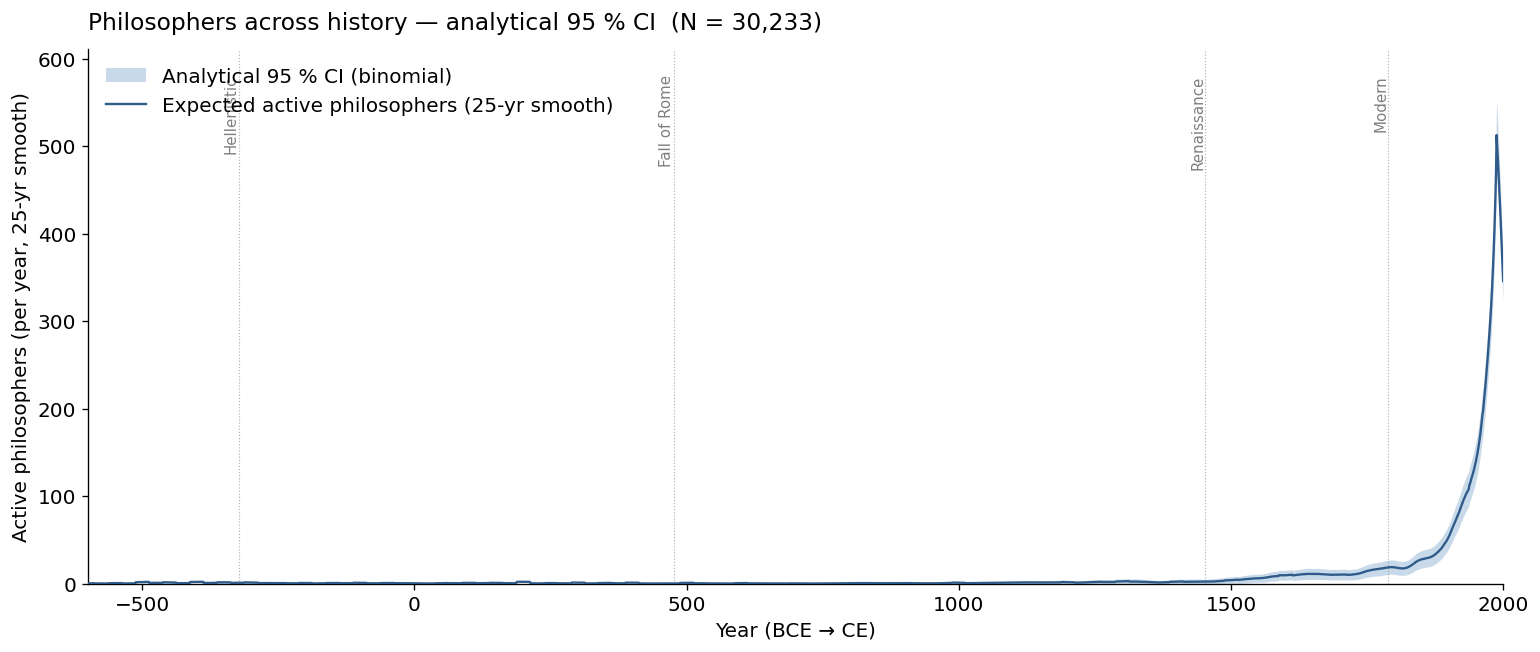

In [12]:
fig, ax = plt.subplots(figsize=(13, 5.6))

ax.fill_between(phil_years, phil_low_s, phil_high_s, color=COL_BAND,
                alpha=0.55, linewidth=0,
                label='Analytical 95 % CI (binomial)', zorder=2)
ax.plot(phil_years, phil_exp_s, color=COL_EXPECTED, linewidth=1.4,
        label='Expected active philosophers (25-yr smooth)', zorder=3)

# Era markers anchored to widely-used historiographic boundaries
era_lines = [(-323, 'Hellenistic'), (476, 'Fall of Rome'),
             (1453, 'Renaissance'), (1789, 'Modern')]
ymax = float(phil_high_s.max()) * 1.05
for x, label in era_lines:
    ax.axvline(x, color=COL_NEUTRAL, linewidth=0.7, linestyle=':', alpha=0.6)
    ax.text(x, ymax, label, rotation=90, fontsize=9,
            ha='right', va='top', color=COL_NEUTRAL)

ax.set_xlim(PHIL_YEAR_MIN, PHIL_YEAR_MAX)
ax.set_ylim(0, ymax * 1.05)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Active philosophers (per year, 25-yr smooth)')
ax.set_title(f'Philosophers across history — analytical 95 % CI  (N = {phil.height:,})',
             loc='left', fontsize=14, pad=12)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
plt.show()


### Decomposition by precision class

The CI is *wide* in antiquity and *tight* in the modern period because the mix
of precision classes shifts. Stack-plot the expected count by class to see
where each contribution lives.


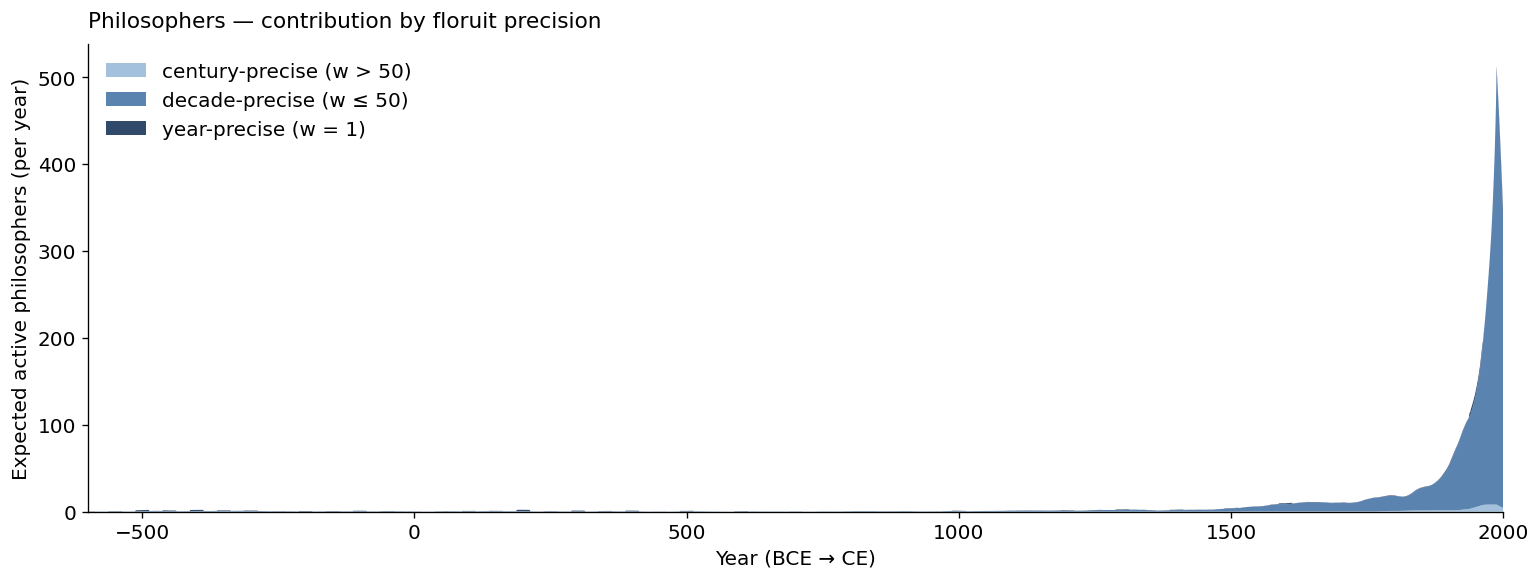

In [13]:
def per_year_expected_window(rows, year_min, year_max):
    n_y = year_max - year_min + 1
    if rows.height == 0:
        return np.zeros(n_y)
    s = rows['s'].to_numpy()
    e = rows['e'].to_numpy()
    w = rows['width_eff'].to_numpy()
    p = 1.0 / w
    de = np.zeros(n_y + 1)
    np.add.at(de, s - year_min,     p)
    np.add.at(de, e - year_min + 1, -p)
    return np.cumsum(de)[:n_y]

phil_year_only    = per_year_expected_window(phil.filter(pl.col('precision') == 'year'),
                                             PHIL_YEAR_MIN, PHIL_YEAR_MAX)
phil_decade_only  = per_year_expected_window(phil.filter(pl.col('precision') == 'decade'),
                                             PHIL_YEAR_MIN, PHIL_YEAR_MAX)
phil_century_only = per_year_expected_window(phil.filter(pl.col('precision') == 'century'),
                                             PHIL_YEAR_MIN, PHIL_YEAR_MAX)

# 25-yr smoothing for readability
phil_year_only_s    = rolling(phil_year_only)
phil_decade_only_s  = rolling(phil_decade_only)
phil_century_only_s = rolling(phil_century_only)

fig, ax = plt.subplots(figsize=(13, 5.0))
ax.stackplot(phil_years,
             phil_century_only_s, phil_decade_only_s, phil_year_only_s,
             colors=[COL_CENTURY, '#4c78a8', COL_EXACT],
             labels=['century-precise (w > 50)',
                     'decade-precise (w ≤ 50)',
                     'year-precise (w = 1)'],
             alpha=0.92, linewidth=0)
ax.set_xlim(PHIL_YEAR_MIN, PHIL_YEAR_MAX)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Expected active philosophers (per year)')
ax.set_title('Philosophers — contribution by floruit precision', loc='left',
             fontsize=13, pad=10)
ax.legend(loc='upper left', frameon=False)
fig.tight_layout()
plt.show()


### Where is the CI wide vs narrow?

Plot the *relative* 95 % half-width $1.96\hat\sigma / \mathbb{E}[Y(y)]$ over time.
This is the metric to use when asking *"how much should I trust the trend at
this date?"* — values close to 0 mean tight, values approaching 1 or beyond
mean the count could plausibly double.


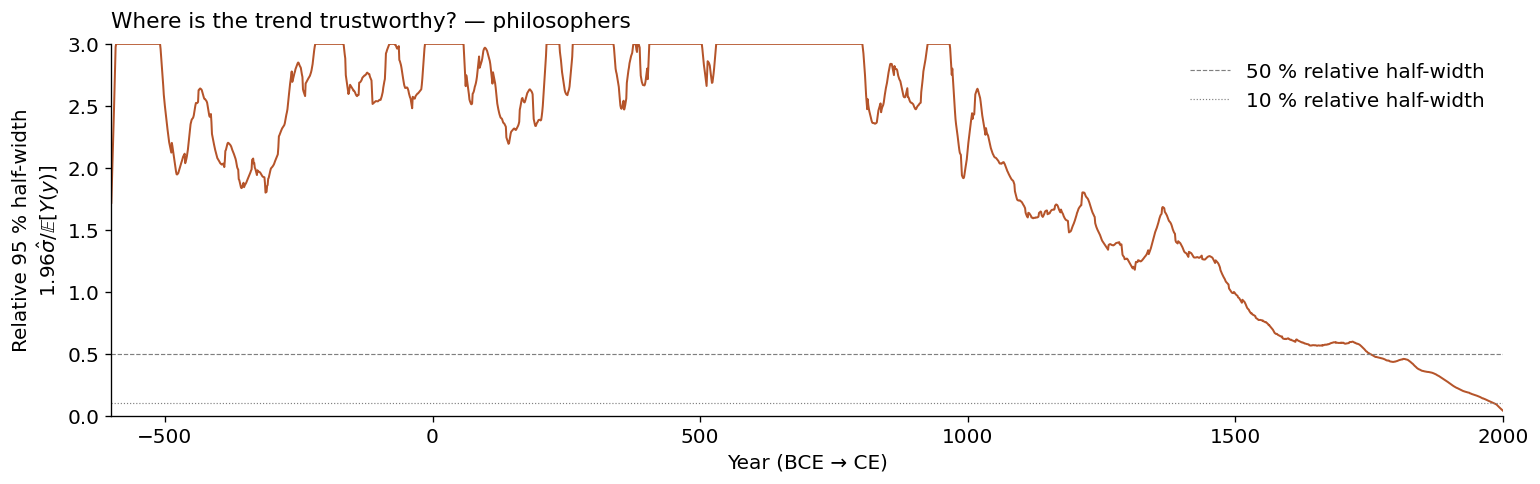

In [14]:
rel_hw = 1.96 * phil_se / np.maximum(phil_exp, 1e-9)
rel_hw_s = rolling(rel_hw)

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(phil_years, np.minimum(rel_hw_s, 3.0), color=COL_MC, linewidth=1.2)
ax.axhline(0.5, color=COL_NEUTRAL, linewidth=0.7, linestyle='--',
           label='50 % relative half-width')
ax.axhline(0.1, color=COL_NEUTRAL, linewidth=0.7, linestyle=':',
           label='10 % relative half-width')
ax.set_xlim(PHIL_YEAR_MIN, PHIL_YEAR_MAX)
ax.set_ylim(0, 3.0)
ax.set_xlabel('Year (BCE → CE)')
ax.set_ylabel('Relative 95 % half-width\n$1.96\\hat\\sigma / \\mathbb{E}[Y(y)]$')
ax.set_title('Where is the trend trustworthy? — philosophers',
             loc='left', fontsize=13, pad=10)
ax.legend(loc='upper right', frameon=False)
fig.tight_layout()
plt.show()


## 11. When Monte-Carlo becomes necessary

The agreement in section 7 is *not* a coincidence — it holds because the
problem here satisfies every assumption the binomial formula needs:

1. each individual's true year is **uniform** inside its floruit window,
2. windows align cleanly with the chosen aggregation grid (per-year),
3. all windows are **independent** of each other.

Monte-Carlo earns its keep the moment any of those break. Concretely:

- **Activity windows that span multiple decades.** If you re-aggregate this
  same data into 10-year bins, a 20-year window straddles **2 or 3 decades**
  depending on where it lands. The contribution to a decade is no longer a
  simple Bernoulli (yes/no) — it depends on the offset of the window relative
  to the bin edge. The closed form gets ugly fast.
- **Windows that leak across bin boundaries.** A century-dated individual with
  midpoint near 1295 and a 20-year window spills into the 1300s. Cross-century
  contamination breaks any clean per-century binomial.
- **Variable window lengths.** If different individuals have window widths
  drawn from a *distribution* (e.g., $w_i \sim \text{LogNormal}$) rather than
  fixed at 1 / 100, the variance term picks up an extra layer of uncertainty
  the analytical formula doesn't capture out of the box.
- **Non-uniform within-window priors.** Section 3 assumes
  $T_i \mid (s_i, e_i) \sim \text{Uniform}$. Drop that — say, weight the second
  half of a century more because life expectancy / source survival favours
  later years — and the closed form has to be re-derived for every prior shape.
- **Dependencies between individuals.** Knowing two individuals were
  contemporaries (same school, same patron, same dated event) induces
  correlation between their $T_i$. The variance is no longer a simple sum;
  cross-terms appear, and the binomial law is the wrong likelihood entirely.

In all five cases the Monte-Carlo recipe (§4) doesn't change — sample, tally,
take percentiles. That robustness is the *real* reason to keep it in the
toolbox even when the analytical formula matches today.

## 12. Takeaway

- The Monte-Carlo and analytical (binomial) routes describe the **same** random
  variable when individuals are assumed uniform within their floruit interval
  *and* windows align with the year grid. Their 95 % bands coincide up to MC
  noise.
- The analytical route is essentially free (one cumulative sum across years), so
  notebook 21 and its companions use it for the production figures and reserve
  Monte-Carlo for cross-checks — and for the situations listed in §11 where the
  closed form no longer applies.
- The CI width is driven by *century-only* individuals (each contributes
  $1/100 \cdot 99/100 \approx 0.0099$ to the variance per year covered), while
  *exact* individuals contribute zero variance to the year they fall in but a
  full $+1$ spike to the expected count there.
- Doubling $N$ shrinks the *relative* half-width by $\sqrt{2}$, as expected for a
  sum of independent contributions.

In short: the question *"how many people were active in year $y$?"* has a flat
expected answer when widths are uniform, but a non-trivial CI whose decade-by-
decade structure encodes which years are anchored by precise data and which
years lean on century-only evidence.